In [27]:
import pandas as pd

dataset = pd.read_csv('merged_dataset.csv')

dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 10624 entries, 0 to 10623
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ano_campeonato                  10624 non-null  int64  
 1   data                            10624 non-null  str    
 2   rodada                          8452 non-null   float64
 3   estadio                         8441 non-null   str    
 4   arbitro                         6742 non-null   str    
 5   publico                         6742 non-null   float64
 6   time_mandante                   10624 non-null  int64  
 7   time_visitante                  10624 non-null  int64  
 8   tecnico_mandante                6299 non-null   str    
 9   tecnico_visitante               6299 non-null   str    
 10  colocacao_mandante              6742 non-null   float64
 11  colocacao_visitante             6742 non-null   float64
 12  valor_equipe_titular_mandante   6355 non-nu

# Preencendo estat'iticas (nao oddd) NaN

## Construindo estatísticas acumuladas para cada time em cada temporada

In [28]:
# Garante que a coluna 'data' está no formato de data e ordena o dataset
dataset['data'] = pd.to_datetime(dataset['data'])
dataset = dataset.sort_values(by=['ano_campeonato', 'data', 'rodada']).reset_index(drop=True)

# Colunas a serem criadas para mandantes e visitantes
stats_cols = [
    'gols_pro', 'gols_sofridos', 'saldo_gols',
    'vitorias', 'empates', 'derrotas'
]
for col in stats_cols:
    dataset[f'{col}_mandante'] = 0
    dataset[f'{col}_visitante'] = 0

# Itera sobre cada temporada
for ano in dataset['ano_campeonato'].unique():
    # Dicionário para armazenar as estatísticas de cada time na temporada
    stats_temporada = {}
    
    # Filtra o dataset para a temporada atual
    df_temporada = dataset[dataset['ano_campeonato'] == ano]

    for index, row in df_temporada.iterrows():
        time_mandante = row['time_mandante']
        time_visitante = row['time_visitante']
        gols_mandante = row['gols_mandante']
        gols_visitante = row['gols_visitante']

        # Inicializa as estatísticas para times novos na temporada
        for time in [time_mandante, time_visitante]:
            if time not in stats_temporada:
                stats_temporada[time] = {col: 0 for col in stats_cols}

        # Atribui as estatísticas acumuladas *antes* do jogo atual
        for col in stats_cols:
            dataset.loc[index, f'{col}_mandante'] = stats_temporada[time_mandante][col]
            dataset.loc[index, f'{col}_visitante'] = stats_temporada[time_visitante][col]

        # Atualiza as estatísticas do time mandante após o jogo
        stats_temporada[time_mandante]['gols_pro'] += gols_mandante
        stats_temporada[time_mandante]['gols_sofridos'] += gols_visitante
        
        # Atualiza as estatísticas do time visitante após o jogo
        stats_temporada[time_visitante]['gols_pro'] += gols_visitante
        stats_temporada[time_visitante]['gols_sofridos'] += gols_mandante

        # Atualiza vitórias, empates e derrotas
        if gols_mandante > gols_visitante:
            stats_temporada[time_mandante]['vitorias'] += 1
            stats_temporada[time_visitante]['derrotas'] += 1
        elif gols_visitante > gols_mandante:
            stats_temporada[time_visitante]['vitorias'] += 1
            stats_temporada[time_mandante]['derrotas'] += 1
        else:
            stats_temporada[time_mandante]['empates'] += 1
            stats_temporada[time_visitante]['empates'] += 1

        # Atualiza o saldo de gols para ambos os times
        stats_temporada[time_mandante]['saldo_gols'] = stats_temporada[time_mandante]['gols_pro'] - stats_temporada[time_mandante]['gols_sofridos']
        stats_temporada[time_visitante]['saldo_gols'] = stats_temporada[time_visitante]['gols_pro'] - stats_temporada[time_visitante]['gols_sofridos']

In [29]:
# Exibe as primeiras linhas com as novas colunas para verificação
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 10624 entries, 0 to 10623
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   ano_campeonato                  10624 non-null  int64         
 1   data                            10624 non-null  datetime64[us]
 2   rodada                          8452 non-null   float64       
 3   estadio                         8441 non-null   str           
 4   arbitro                         6742 non-null   str           
 5   publico                         6742 non-null   float64       
 6   time_mandante                   10624 non-null  int64         
 7   time_visitante                  10624 non-null  int64         
 8   tecnico_mandante                6299 non-null   str           
 9   tecnico_visitante               6299 non-null   str           
 10  colocacao_mandante              6742 non-null   float64       
 11  colocacao_vis

In [30]:
# Ordena o dataset para garantir que os jogos estão em ordem cronológica dentro de cada temporada
dataset = dataset.sort_values(by=['ano_campeonato', 'data']).reset_index(drop=True)

# Itera sobre cada temporada para preencher a coluna 'rodada'
for ano in dataset['ano_campeonato'].unique():
    # Filtra o dataset para a temporada atual
    df_temporada = dataset[dataset['ano_campeonato'] == ano]
    
    # Obtém a lista de todos os times únicos na temporada
    times_na_temporada = pd.concat([df_temporada['time_mandante'], df_temporada['time_visitante']]).unique()
    
    rodada_atual = 1
    times_jogaram_na_rodada = set()
    
    # Itera sobre os jogos da temporada em ordem cronológica
    for index, row in df_temporada.iterrows():
        # Se a rodada já estiver preenchida, pula para o próximo
        if pd.notna(dataset.loc[index, 'rodada']):
            continue

        time_mandante = row['time_mandante']
        time_visitante = row['time_visitante']
        
        # Verifica se os times já jogaram nesta rodada
        if time_mandante in times_jogaram_na_rodada or time_visitante in times_jogaram_na_rodada:
            # Se um dos times já jogou, significa que uma nova rodada começou
            rodada_atual += 1
            times_jogaram_na_rodada = {time_mandante, time_visitante}
        else:
            # Adiciona os times ao conjunto de times que jogaram na rodada atual
            times_jogaram_na_rodada.add(time_mandante)
            times_jogaram_na_rodada.add(time_visitante)

        # Atribui o número da rodada ao jogo atual
        dataset.loc[index, 'rodada'] = rodada_atual

# Converte a coluna 'rodada' para inteiro, pois não haverá mais NaNs
dataset['rodada'] = dataset['rodada'].astype(int)

print("Preenchimento da coluna 'rodada' concluído.")
dataset[['ano_campeonato', 'data', 'rodada', 'time_mandante', 'time_visitante']].tail(10)

Preenchimento da coluna 'rodada' concluído.


,ano_campeonato,data,rodada,time_mandante,time_visitante
10614,2026,2026-05-16,18,4,47
10615,2026,2026-05-16,18,22,45
10616,2026,2026-05-16,18,28,46
10617,2026,2026-05-17,18,2,21
10618,2026,2026-05-17,18,8,13
10619,2026,2026-05-17,18,12,48
10620,2026,2026-05-17,18,18,26
10621,2026,2026-05-17,18,33,16
10622,2026,2026-05-17,18,38,19
10623,2026,2026-05-17,18,41,14


In [ ]:
# Itera sobre cada temporada para calcular as colocações
for ano in sorted(dataset['ano_campeonato'].unique()):
    # Filtra o dataset para a temporada atual
    df_temporada = dataset[dataset['ano_campeonato'] == ano].copy()
    
    # Itera sobre cada rodada da temporada
    for rodada in sorted(df_temporada['rodada'].unique()):
        # Pula rodadas com valor NaN
        if pd.isna(rodada):
            continue

        # Filtra os jogos da rodada atual
        jogos_rodada = df_temporada[df_temporada['rodada'] == rodada]
        
        # Para a primeira rodada, a colocação é baseada no valor da equipe
        if rodada == 1:
            times_valores = {}
            for _, row in jogos_rodada.iterrows():
                times_valores[row['time_mandante']] = row['time_mandante']
                times_valores[row['time_visitante']] = row['time_visitante']

            # Se não houver valores de equipe, pula para a próxima rodada
            if not times_valores:
                continue

            df_valores = pd.DataFrame(list(times_valores.items()), columns=['time', 'valor_equipe'])
            df_valores = df_valores.sort_values(by='valor_equipe', ascending=False).reset_index(drop=True)
            df_valores['colocacao'] = df_valores.index + 1
            
            mapa_colocacao_rodada_1 = df_valores.set_index('time')['colocacao'].to_dict()

            for index, row in jogos_rodada.iterrows():
                if pd.isna(dataset.loc[index, 'colocacao_mandante']):
                    dataset.loc[index, 'colocacao_mandante'] = mapa_colocacao_rodada_1.get(row['time_mandante'])
                if pd.isna(dataset.loc[index, 'colocacao_visitante']):
                    dataset.loc[index, 'colocacao_visitante'] = mapa_colocacao_rodada_1.get(row['time_visitante'])
            continue

        # Coleta as estatísticas de todos os times antes desta rodada
        stats_antes_rodada = {}
        times_na_temporada = pd.concat([df_temporada['time_mandante'], df_temporada['time_visitante']]).unique()

        for time in times_na_temporada:
            # Encontra a última partida do time antes da rodada atual
            partidas_anteriores = df_temporada[(df_temporada['rodada'] < rodada) & 
                                               ((df_temporada['time_mandante'] == time) | (df_temporada['time_visitante'] == time))]
            
            if not partidas_anteriores.empty:
                # Ordena para garantir que estamos pegando a partida mais recente antes da rodada atual
                ultima_partida = partidas_anteriores.sort_values(by='data', ascending=False).iloc[0]
                
                if ultima_partida['time_mandante'] == time:
                    stats_time = {
                        'vitorias': ultima_partida['vitorias_mandante'],
                        'empates': ultima_partida['empates_mandante'],
                        'saldo_gols': ultima_partida['saldo_gols_mandante'],
                        'gols_pro': ultima_partida['gols_pro_mandante']
                    }
                else: # time visitante
                    stats_time = {
                        'vitorias': ultima_partida['vitorias_visitante'],
                        'empates': ultima_partida['empates_visitante'],
                        'saldo_gols': ultima_partida['saldo_gols_visitante'],
                        'gols_pro': ultima_partida['gols_pro_visitante']
                    }
                stats_antes_rodada[time] = stats_time
            else: # Time não jogou ainda na temporada antes desta rodada
                 stats_antes_rodada[time] = {'vitorias': 0, 'empates': 0, 'saldo_gols': 0, 'gols_pro': 0}

        # Constrói a tabela de classificação
        if not stats_antes_rodada:
            continue
            
        tabela_classificacao = pd.DataFrame.from_dict(stats_antes_rodada, orient='index')
        tabela_classificacao['pontos'] = tabela_classificacao['vitorias'] * 3 + tabela_classificacao['empates']
        
        tabela_classificacao = tabela_classificacao.sort_values(
            by=['pontos', 'vitorias', 'saldo_gols', 'gols_pro'],
            ascending=[False, False, False, False]
        ).reset_index()
        tabela_classificacao['colocacao'] = tabela_classificacao.index + 1
        tabela_classificacao = tabela_classificacao.rename(columns={'index': 'time'})
        
        mapa_colocacao = tabela_classificacao.set_index('time')['colocacao'].to_dict()

        # Atualiza as colocações no dataset principal para os jogos da rodada
        for index, row in jogos_rodada.iterrows():
            if pd.isna(dataset.loc[index, 'colocacao_mandante']):
                dataset.loc[index, 'colocacao_mandante'] = mapa_colocacao.get(row['time_mandante'])
            if pd.isna(dataset.loc[index, 'colocacao_visitante']):
                dataset.loc[index, 'colocacao_visitante'] = mapa_colocacao.get(row['time_visitante'])

print("Preenchimento das colocações concluído.")


AttributeError: 'numpy.float64' object has no attribute 'isna'

In [ ]:
dataset[['ano_campeonato', 'rodada', 'time_mandante', 'colocacao_mandante', 'time_visitante', 'colocacao_visitante']].tail(10)

,ano_campeonato,rodada,time_mandante,colocacao_mandante,time_visitante,colocacao_visitante
10614,2026,18,4,11.0,47,18.0
10615,2026,18,22,3.0,45,4.0
10616,2026,18,28,12.0,46,13.0
10617,2026,18,2,5.0,21,2.0
10618,2026,18,8,10.0,13,17.0
10619,2026,18,12,20.0,48,19.0
10620,2026,18,18,6.0,26,14.0
10621,2026,18,33,1.0,16,15.0
10622,2026,18,38,7.0,19,9.0
10623,2026,18,41,16.0,14,8.0


In [ ]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 10624 entries, 0 to 10623
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   ano_campeonato                  10624 non-null  int64         
 1   data                            10624 non-null  datetime64[us]
 2   rodada                          10624 non-null  int64         
 3   estadio                         8441 non-null   str           
 4   arbitro                         6742 non-null   str           
 5   publico                         6742 non-null   float64       
 6   time_mandante                   10624 non-null  int64         
 7   time_visitante                  10624 non-null  int64         
 8   tecnico_mandante                6299 non-null   str           
 9   tecnico_visitante               6299 non-null   str           
 10  colocacao_mandante              10624 non-null  float64       
 11  colocacao_vis

In [ ]:
# Calcula a média de público por estádio em cada temporada
media_por_temporada_estadio = dataset.groupby(['ano_campeonato', 'estadio'])['publico'].transform('mean')
dataset['publico'] = dataset['publico'].fillna(media_por_temporada_estadio)

# Para os casos restantes, calcula a média de público por estádio em todas as temporadas
media_geral_estadio = dataset.groupby('estadio')['publico'].transform('mean')
dataset['publico'] = dataset['publico'].fillna(media_geral_estadio)

# Se ainda houver NaNs (estádios sem nenhum registro de público), preenche com a média geral de público
media_geral_total = dataset['publico'].mean()
dataset['publico'] = dataset['publico'].fillna(media_geral_total)

print(dataset.info())

<class 'pandas.DataFrame'>
RangeIndex: 10624 entries, 0 to 10623
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   ano_campeonato                  10624 non-null  int64         
 1   data                            10624 non-null  datetime64[us]
 2   rodada                          10624 non-null  int64         
 3   estadio                         8441 non-null   str           
 4   arbitro                         6742 non-null   str           
 5   publico                         10624 non-null  float64       
 6   time_mandante                   10624 non-null  int64         
 7   time_visitante                  10624 non-null  int64         
 8   tecnico_mandante                6299 non-null   str           
 9   tecnico_visitante               6299 non-null   str           
 10  colocacao_mandante              10624 non-null  float64       
 11  colocacao_vis

In [ ]:
import numpy as np

# Função para calcular a média ponderada baseada no tempo
def calcular_valor_ponderado(time, data_jogo, df):
    # Encontra todos os jogos anteriores do time onde o valor da equipe é conhecido
    jogos_anteriores_mandante = df[(df['time_mandante'] == time) & (df['data'] < data_jogo) & (df['valor_equipe_titular_mandante'].notna())]
    jogos_anteriores_visitante = df[(df['time_visitante'] == time) & (df['data'] < data_jogo) & (df['valor_equipe_titular_visitante'].notna())]

    valores = []
    pesos = []

    # Coleta valores e calcula pesos para jogos como mandante
    for _, row in jogos_anteriores_mandante.iterrows():
        delta_tempo = (data_jogo - row['data']).days / 365.25
        if delta_tempo > 0:
            valores.append(row['valor_equipe_titular_mandante'])
            pesos.append(1 / delta_tempo)

    # Coleta valores e calcula pesos para jogos como visitante
    for _, row in jogos_anteriores_visitante.iterrows():
        delta_tempo = (data_jogo - row['data']).days / 365.25
        if delta_tempo > 0:
            valores.append(row['valor_equipe_titular_visitante'])
            pesos.append(1 / delta_tempo)

    # Se houver valores históricos, calcula a média ponderada
    if pesos:
        return np.average(valores, weights=pesos)
    else:
        # Se não houver histórico, retorna NaN para ser tratado depois
        return np.nan

# Itera sobre as linhas com valores NaN para preenchê-los
for col_valor, col_time in [('valor_equipe_titular_mandante', 'time_mandante'), ('valor_equipe_titular_visitante', 'time_visitante')]:
    # Seleciona as linhas que precisam de preenchimento
    indices_nan = dataset[dataset[col_valor].isna()].index
    
    for index in indices_nan:
        # Pega o time e a data do jogo atual
        time = dataset.loc[index, col_time]
        data_jogo = dataset.loc[index, 'data']
        
        # Calcula o valor ponderado
        valor_calculado = calcular_valor_ponderado(time, data_jogo, dataset)                                                                                                                                                              
        
        # Atribui o valor calculado à célula correspondente
        dataset.loc[index, col_valor] = valor_calculado

# Para os casos restantes (times sem nenhum registro anterior), preenche com a média do valor da equipe em toda a base
media_geral_mandante = dataset['valor_equipe_titular_mandante'].mean()
media_geral_visitante = dataset['valor_equipe_titular_visitante'].mean()

dataset['valor_equipe_titular_mandante'] = dataset['valor_equipe_titular_mandante'].fillna(media_geral_mandante)
dataset['valor_equipe_titular_visitante'] = dataset['valor_equipe_titular_visitante'].fillna(media_geral_visitante)

print("Preenchimento dos valores de equipe concluído.")
dataset.info()

Preenchimento dos valores de equipe concluído.
<class 'pandas.DataFrame'>
RangeIndex: 10624 entries, 0 to 10623
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   ano_campeonato                  10624 non-null  int64         
 1   data                            10624 non-null  datetime64[us]
 2   rodada                          10624 non-null  int64         
 3   estadio                         8441 non-null   str           
 4   arbitro                         6742 non-null   str           
 5   publico                         10624 non-null  float64       
 6   time_mandante                   10624 non-null  int64         
 7   time_visitante                  10624 non-null  int64         
 8   tecnico_mandante                6299 non-null   str           
 9   tecnico_visitante               6299 non-null   str           
 10  colocacao_mandante              10

In [ ]:
# Criar uma série com a idade média de cada time, desconsiderando se é mandante ou visitante
idade_mandante = dataset[['time_mandante', 'idade_media_titular_mandante']].rename(columns={'time_mandante': 'time', 'idade_media_titular_mandante': 'idade'})
idade_visitante = dataset[['time_visitante', 'idade_media_titular_visitante']].rename(columns={'time_visitante': 'time', 'idade_media_titular_visitante': 'idade'})

# Concatenar e calcular a média de idade por time
media_idade_por_time = pd.concat([idade_mandante, idade_visitante]).dropna().groupby('time')['idade'].mean()

# Mapear as médias para as colunas de mandante e visitante
dataset['idade_media_titular_mandante'] = dataset['idade_media_titular_mandante'].fillna(dataset['time_mandante'].map(media_idade_por_time))
dataset['idade_media_titular_visitante'] = dataset['idade_media_titular_visitante'].fillna(dataset['time_visitante'].map(media_idade_por_time))

# Para casos onde um time pode não ter nenhum registro de idade (improvável, mas para garantir)
# Preenche com a média geral da coluna
media_geral_idade_mandante = dataset['idade_media_titular_mandante'].mean()
media_geral_idade_visitante = dataset['idade_media_titular_visitante'].mean()

dataset['idade_media_titular_mandante'] = dataset['idade_media_titular_mandante'].fillna(media_geral_idade_mandante)
dataset['idade_media_titular_visitante'] = dataset['idade_media_titular_visitante'].fillna(media_geral_idade_visitante)

dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 10624 entries, 0 to 10623
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   ano_campeonato                  10624 non-null  int64         
 1   data                            10624 non-null  datetime64[us]
 2   rodada                          10624 non-null  int64         
 3   estadio                         8441 non-null   str           
 4   arbitro                         6742 non-null   str           
 5   publico                         10624 non-null  float64       
 6   time_mandante                   10624 non-null  int64         
 7   time_visitante                  10624 non-null  int64         
 8   tecnico_mandante                6299 non-null   str           
 9   tecnico_visitante               6299 non-null   str           
 10  colocacao_mandante              10624 non-null  float64       
 11  colocacao_vis

In [ ]:
for ano in dataset['ano_campeonato'].unique():
    # Encontra o árbitro mais frequente (moda) para a temporada atual, ignorando NaNs
    moda_arbitro = dataset[dataset['ano_campeonato'] == ano]['arbitro'].mode()
    
    if not moda_arbitro.empty:
        arbitro_mais_comum = moda_arbitro[0]
        
        # Preenche os NaNs da coluna 'arbitro' para a temporada atual com a moda encontrada
        dataset.loc[(dataset['ano_campeonato'] == ano) & (dataset['arbitro'].isna()), 'arbitro'] = arbitro_mais_comum

# Se ainda houver algum NaN (ex: uma temporada inteira sem dados de árbitro), preenche com a moda geral
moda_geral_arbitro = dataset['arbitro'].mode()[0]
dataset['arbitro'] = dataset['arbitro'].fillna(moda_geral_arbitro)

dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 10624 entries, 0 to 10623
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   ano_campeonato                  10624 non-null  int64         
 1   data                            10624 non-null  datetime64[us]
 2   rodada                          10624 non-null  int64         
 3   estadio                         8441 non-null   str           
 4   arbitro                         10624 non-null  str           
 5   publico                         10624 non-null  float64       
 6   time_mandante                   10624 non-null  int64         
 7   time_visitante                  10624 non-null  int64         
 8   tecnico_mandante                6299 non-null   str           
 9   tecnico_visitante               6299 non-null   str           
 10  colocacao_mandante              10624 non-null  float64       
 11  colocacao_vis

In [ ]:
for ano in dataset['ano_campeonato'].unique():
    df_temporada = dataset[dataset['ano_campeonato'] == ano]
    times_temporada = pd.concat([df_temporada['time_mandante'], df_temporada['time_visitante']]).unique()

    for time in times_temporada:
        # Coleta todos os técnicos para um time na temporada, tanto como mandante quanto visitante
        tecnicos_mandante = df_temporada[df_temporada['time_mandante'] == time]['tecnico_mandante']
        tecnicos_visitante = df_temporada[df_temporada['time_visitante'] == time]['tecnico_visitante']
        
        todos_tecnicos = pd.concat([tecnicos_mandante, tecnicos_visitante]).dropna()
        
        if not todos_tecnicos.empty:
            # Encontra o técnico mais frequente (moda)
            moda_tecnico = todos_tecnicos.mode()[0]
            
            # Preenche NaNs para o time como mandante na temporada
            dataset.loc[(dataset['ano_campeonato'] == ano) & (dataset['time_mandante'] == time) & (dataset['tecnico_mandante'].isna()), 'tecnico_mandante'] = moda_tecnico
            
            # Preenche NaNs para o time como visitante na temporada
            dataset.loc[(dataset['ano_campeonato'] == ano) & (dataset['time_visitante'] == time) & (dataset['tecnico_visitante'].isna()), 'tecnico_visitante'] = moda_tecnico

# Para casos onde um time possa não ter nenhum registro de técnico em uma temporada (improvável)
# Preenche com a moda geral da respectiva coluna
moda_geral_tecnico_mandante = dataset['tecnico_mandante'].mode()[0]
moda_geral_tecnico_visitante = dataset['tecnico_visitante'].mode()[0]

dataset['tecnico_mandante'] = dataset['tecnico_mandante'].fillna(moda_geral_tecnico_mandante)
dataset['tecnico_visitante'] = dataset['tecnico_visitante'].fillna(moda_geral_tecnico_visitante)

dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 10624 entries, 0 to 10623
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   ano_campeonato                  10624 non-null  int64         
 1   data                            10624 non-null  datetime64[us]
 2   rodada                          10624 non-null  int64         
 3   estadio                         8441 non-null   str           
 4   arbitro                         10624 non-null  str           
 5   publico                         10624 non-null  float64       
 6   time_mandante                   10624 non-null  int64         
 7   time_visitante                  10624 non-null  int64         
 8   tecnico_mandante                10624 non-null  str           
 9   tecnico_visitante               10624 non-null  str           
 10  colocacao_mandante              10624 non-null  float64       
 11  colocacao_vis

In [ ]:
# Encontra o estádio mais frequente para cada time mandante
estadio_mais_frequente_por_time = dataset.dropna(subset=['estadio']).groupby('time_mandante')['estadio'].apply(lambda x: x.mode()[0])

# Preenche os valores NaN na coluna 'estadio' usando o mapa criado
# Apenas para as linhas onde 'estadio' é NaN
for index, row in dataset[dataset['estadio'].isna()].iterrows():
    time_mandante = row['time_mandante']
    if time_mandante in estadio_mais_frequente_por_time:
        dataset.loc[index, 'estadio'] = estadio_mais_frequente_por_time[time_mandante]

# Para qualquer time que ainda possa ter NaN (se nunca jogou como mandante com um estádio registrado)
# Preenche com a moda geral de estádios
if dataset['estadio'].isna().any():
    moda_geral_estadio = dataset['estadio'].mode()[0]
    dataset['estadio'] = dataset['estadio'].fillna(moda_geral_estadio)

dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 10624 entries, 0 to 10623
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   ano_campeonato                  10624 non-null  int64         
 1   data                            10624 non-null  datetime64[us]
 2   rodada                          10624 non-null  int64         
 3   estadio                         10624 non-null  str           
 4   arbitro                         10624 non-null  str           
 5   publico                         10624 non-null  float64       
 6   time_mandante                   10624 non-null  int64         
 7   time_visitante                  10624 non-null  int64         
 8   tecnico_mandante                10624 non-null  str           
 9   tecnico_visitante               10624 non-null  str           
 10  colocacao_mandante              10624 non-null  float64       
 11  colocacao_vis

## Label encoder

In [ ]:
# poderia tirar estadios, arbitro e tecnicos com one hot encoding (pessimo pq adiciona muitas colunas),
#  usar labelencoder(cardinalidade)+embeddings (melhor pq mantém a cardinalidade e não adiciona colunas)
# ou construir uma metrica personalidade EX:
# estadio pode virar uma coluna "joga em casa" binaria, mas essa info ja esta encodada em "time_mandante"
# alem de perder o fit no "clima de bom jogo" que alguns estadios podem ter
# e perder casos especificos em que um mandante nao joga em casa (e pode ser prejudicado)

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
dataset['estadio'] = label_encoder.fit_transform(dataset['estadio'])

dataset['arbitro'] = label_encoder.fit_transform(dataset['arbitro'])

dataset['tecnico_mandante'] = label_encoder.fit_transform(dataset['tecnico_mandante'])
dataset['tecnico_visitante'] = label_encoder.fit_transform(dataset['tecnico_visitante'])

dataset.iloc[:, dataset.columns.isin(['estadio', 'arbitro', 'tecnico_mandante', 'tecnico_visitante'])].describe()

,estadio,arbitro,tecnico_mandante,tecnico_visitante
count,10624.000000,10624.000000,10624.000000,10624.000000
mean,40.334808,104.650979,107.484281,105.181852
std,23.989863,57.307756,75.940214,74.430234
min,0.000000,0.000000,0.000000,0.000000
25%,20.000000,45.000000,42.000000,41.000000
50%,44.000000,108.000000,87.000000,86.000000
75%,62.000000,162.000000,174.000000,171.000000
max,83.000000,207.000000,258.000000,253.000000


In [ ]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 10624 entries, 0 to 10623
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   ano_campeonato                  10624 non-null  int64         
 1   data                            10624 non-null  datetime64[us]
 2   rodada                          10624 non-null  int64         
 3   estadio                         10624 non-null  int64         
 4   arbitro                         10624 non-null  int64         
 5   publico                         10624 non-null  float64       
 6   time_mandante                   10624 non-null  int64         
 7   time_visitante                  10624 non-null  int64         
 8   tecnico_mandante                10624 non-null  int64         
 9   tecnico_visitante               10624 non-null  int64         
 10  colocacao_mandante              10624 non-null  float64       
 11  colocacao_vis

## Transformando Data em dados

In [ ]:
dataset['dia'] = dataset['data'].dt.day
dataset['mes'] = dataset['data'].dt.month

dataset['dia_sin'] = np.sin(2 * np.pi * dataset['dia']/30)
dataset['dia_cos'] = np.cos(2 * np.pi * dataset['dia']/30)
dataset['mes_sin'] = np.sin(2 * np.pi * dataset['mes']/12)
dataset['mes_cos'] = np.cos(2 * np.pi * dataset['mes']/12)

dataset.drop(columns=['data'], inplace=True)

dataset[['dia', 'mes', 'dia_sin', 'dia_cos', 'mes_sin', 'mes_cos']].head()

,dia,mes,dia_sin,dia_cos,mes_sin,mes_cos
0,29,3,-2.079117e-01,0.978148,1.0,6.123234e-17
1,29,3,-2.079117e-01,0.978148,1.0,6.123234e-17
2,30,3,-1.133108e-15,1.000000,1.0,6.123234e-17
3,30,3,-1.133108e-15,1.000000,1.0,6.123234e-17
4,30,3,-1.133108e-15,1.000000,1.0,6.123234e-17


# odds

In [ ]:
'''
# as odds dependem tanto do periodo temporal quanto de aspectos como sequencia de vitorias, time mandante, time visitante, etc
# portanto utiliza-se um imputer mais sofisticado, como o KNNImputer, que leva em conta a similaridade entre os registros para preencher os valores faltantes de forma mais contextualizada.
'''

from sklearn.impute import KNNImputer

# Seleciona as colunas que serão usadas como features para o imputer
# Exclui colunas categóricas já encodadas, identificadores e as próprias colunas de target (Avg*)
feature_cols = [col for col in dataset.columns if dataset[col].dtype in ['int64', 'float64'] and col not in ['AvgCH', 'AvgCD', 'AvgCA']]

# Instancia o KNNImputer
imputer = KNNImputer(n_neighbors=5)

# Aplica o imputer no dataset. O resultado é um array numpy.
# Usamos apenas as colunas de features e as que queremos preencher.
cols_to_impute = feature_cols + ['AvgCH', 'AvgCD', 'AvgCA']
dataset_imputed = imputer.fit_transform(dataset[cols_to_impute])

# Cria um DataFrame temporário com os dados imputados
df_imputed = pd.DataFrame(dataset_imputed, columns=cols_to_impute, index=dataset.index)

# Atualiza as colunas originais com os valores preenchidos
for col in ['AvgCH', 'AvgCD', 'AvgCA']:
    dataset[col] = df_imputed[col]

dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 10624 entries, 0 to 10623
Data columns (total 38 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ano_campeonato                  10624 non-null  int64  
 1   rodada                          10624 non-null  int64  
 2   estadio                         10624 non-null  int64  
 3   arbitro                         10624 non-null  int64  
 4   publico                         10624 non-null  float64
 5   time_mandante                   10624 non-null  int64  
 6   time_visitante                  10624 non-null  int64  
 7   tecnico_mandante                10624 non-null  int64  
 8   tecnico_visitante               10624 non-null  int64  
 9   colocacao_mandante              10624 non-null  float64
 10  colocacao_visitante             10624 non-null  float64
 11  valor_equipe_titular_mandante   10624 non-null  float64
 12  valor_equipe_titular_visitante  10624 non-n

# Resultado

In [ ]:
conditions = [
    (dataset['gols_mandante'] > dataset['gols_visitante']),
    (dataset['gols_mandante'] < dataset['gols_visitante'])
]

choices = [1, -1]

dataset['resultado_partida'] = np.select(conditions, choices, default=0)

dataset[['gols_mandante', 'gols_visitante', 'resultado_partida']].tail(10)

,gols_mandante,gols_visitante,resultado_partida
10614,3.0,1.0,1
10615,2.0,1.0,1
10616,4.0,1.0,1
10617,1.0,1.0,0
10618,3.0,1.0,1
10619,2.0,3.0,-1
10620,1.0,1.0,0
10621,1.0,1.0,0
10622,2.0,0.0,1
10623,0.0,3.0,-1


In [ ]:
print(dataset.info())

dataset.to_csv('dataset_preprocessed.csv', index=False)

<class 'pandas.DataFrame'>
RangeIndex: 10624 entries, 0 to 10623
Data columns (total 39 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ano_campeonato                  10624 non-null  int64  
 1   rodada                          10624 non-null  int64  
 2   estadio                         10624 non-null  int64  
 3   arbitro                         10624 non-null  int64  
 4   publico                         10624 non-null  float64
 5   time_mandante                   10624 non-null  int64  
 6   time_visitante                  10624 non-null  int64  
 7   tecnico_mandante                10624 non-null  int64  
 8   tecnico_visitante               10624 non-null  int64  
 9   colocacao_mandante              10624 non-null  float64
 10  colocacao_visitante             10624 non-null  float64
 11  valor_equipe_titular_mandante   10624 non-null  float64
 12  valor_equipe_titular_visitante  10624 non-n

# normalizacao

In [ ]:
dataset.describe()

,ano_campeonato,rodada,estadio,arbitro,publico,time_mandante,time_visitante,tecnico_mandante,tecnico_visitante,colocacao_mandante,...,empates_visitante,derrotas_mandante,derrotas_visitante,dia,mes,dia_sin,dia_cos,mes_sin,mes_cos,resultado_partida
count,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,...,10624.000000,10624.000000,10624.000000,10624.000000,10624.000000,1.062400e+04,10624.000000,1.062400e+04,10624.000000,10624.000000
mean,2014.453972,19.195783,40.334808,104.650979,16108.331581,23.105892,23.105233,107.484281,105.181852,11.185429,...,5.728633,7.684111,7.618882,15.809111,7.991152,3.499776e-03,0.020440,-4.317928e-01,-0.182025,0.258001
std,6.558389,11.087327,23.989863,57.307756,11544.889924,13.391040,13.377299,75.940214,74.430234,6.220392,...,4.101171,5.714915,5.746994,8.833865,2.298311,7.022382e-01,0.711706,5.622928e-01,0.681412,0.817408
min,2003.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,-9.945219e-01,-1.000000,-1.000000e+00,-1.000000,-1.000000
25%,2009.000000,10.000000,20.000000,45.000000,8383.000000,13.000000,13.000000,42.000000,41.000000,6.000000,...,2.000000,3.000000,3.000000,8.000000,6.000000,-7.431448e-01,-0.669131,-8.660254e-01,-0.866025,0.000000
50%,2015.000000,19.000000,44.000000,108.000000,16108.331581,22.000000,22.000000,87.000000,86.000000,11.000000,...,5.000000,7.000000,7.000000,16.000000,8.000000,5.665539e-16,0.104528,-5.000000e-01,-0.500000,0.000000
75%,2020.000000,29.000000,62.000000,162.000000,19722.250000,33.000000,33.000000,174.000000,171.000000,16.000000,...,8.000000,11.000000,11.000000,23.000000,10.000000,7.431448e-01,0.669131,1.224647e-16,0.500000,1.000000
max,2026.000000,48.000000,83.000000,207.000000,82044.000000,48.000000,48.000000,258.000000,253.000000,24.000000,...,23.000000,36.000000,35.000000,31.000000,12.000000,9.945219e-01,1.000000,1.000000e+00,1.000000,1.000000


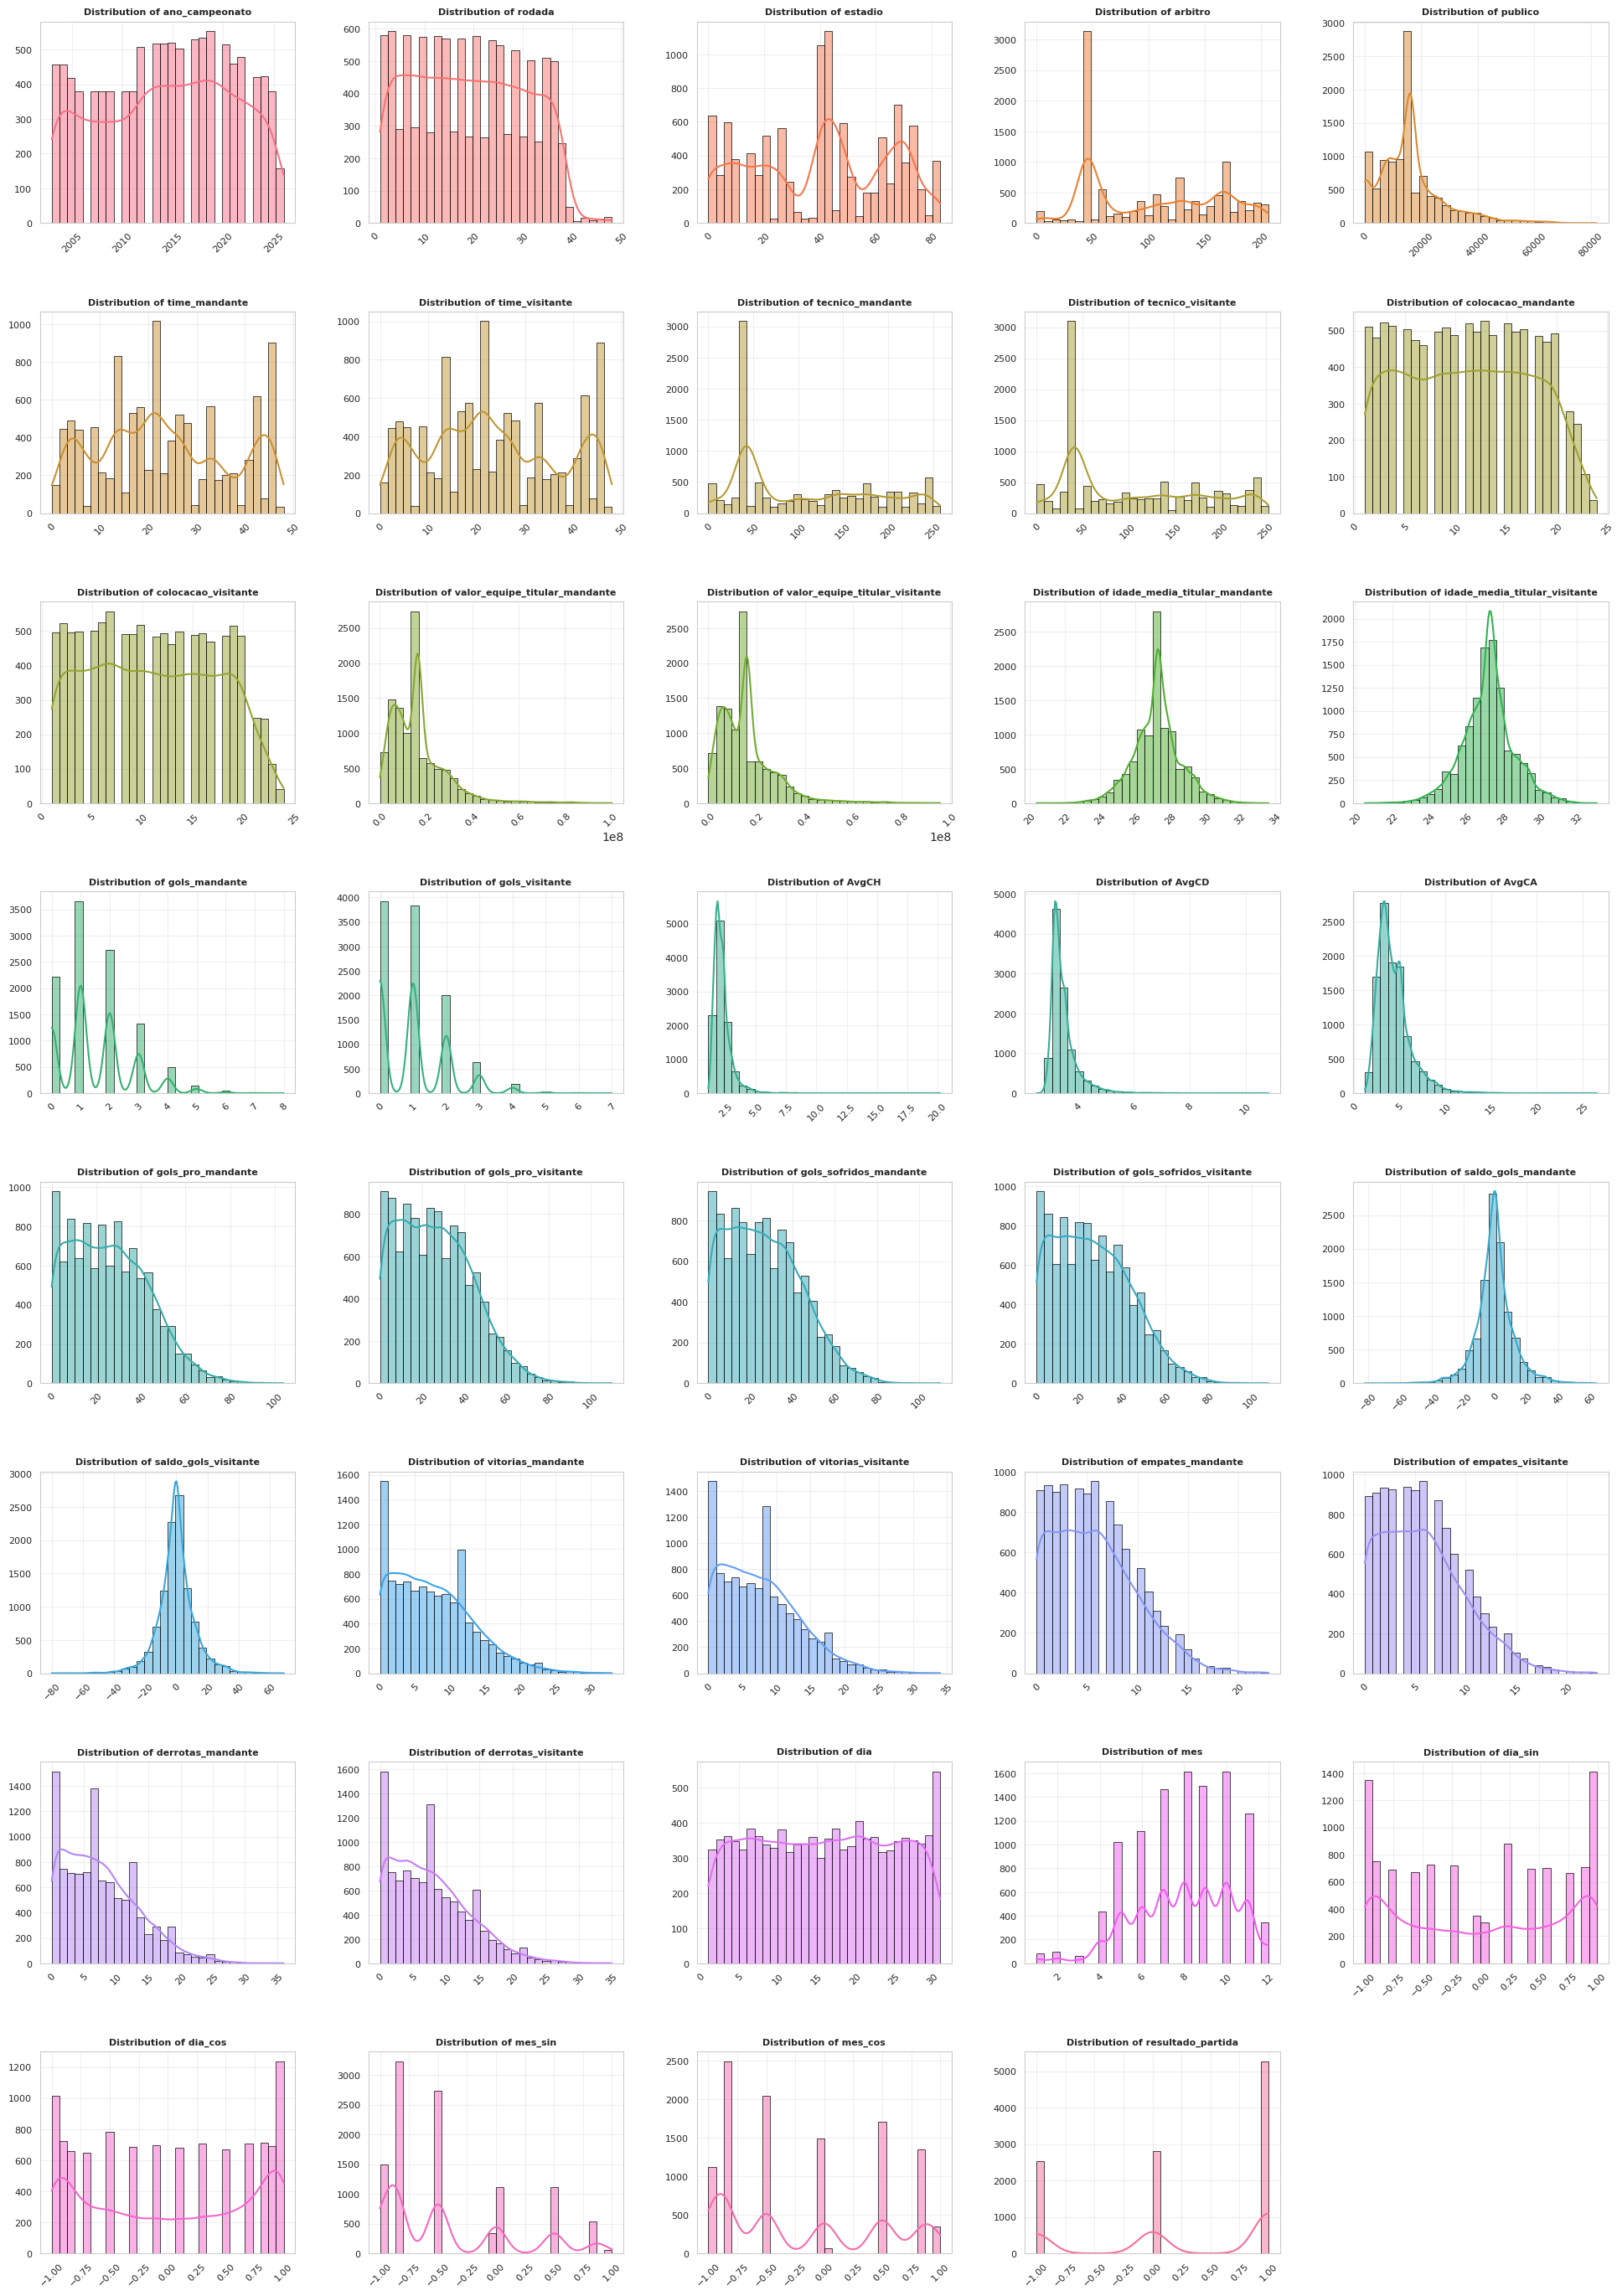

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set a visually appealing style for the plots
sns.set_style('whitegrid')

# Get the list of all columns in the dataset
columns = dataset.columns
num_columns = len(columns)

# Define the grid size
n_rows = 8
n_cols = 5

# Create the subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 28))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Create a color palette
palette = sns.color_palette("husl", num_columns)

# Loop through the columns and plot a histogram for each
for i, col in enumerate(columns):
    sns.histplot(dataset[col], kde=True, ax=axes[i], bins=30, color=palette[i], edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'Distribution of {col}', fontsize=8, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    axes[i].tick_params(axis='y', labelsize=8)
    axes[i].grid(alpha=0.3)

# Hide any unused subplots
for i in range(num_columns, len(axes)):
    axes[i].set_visible(False)

# Adjust the layout to prevent titles and labels from overlapping
plt.tight_layout(pad=3.0)

# Display the plots
plt.show()